<a href="https://colab.research.google.com/github/abhinandantanwar/ITA-assignments/blob/main/Loan%20Defaults%20Prediction%20using%20Random%20Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [ ]:
df = pd.read_csv("Loan Default Prediction Dataset export 2026-03-06 17-32-20.csv")

print("Shape:", df.shape)
df.head()

Shape: (255347, 18)


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [ ]:
# Drop ID column
if "LoanID" in df.columns:
    df = df.drop(columns=["LoanID"])

# Target
target = "Default"

X = df.drop(columns=[target])
y = df[target]

print("Class Distribution:")
print(y.value_counts(normalize=True))

Class Distribution:
Default
0    0.883872
1    0.116128
Name: proportion, dtype: float64


In [ ]:
num_cols = X.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']
Categorical Columns: ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ],
    remainder="passthrough"
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    n_jobs=-1,
    random_state=42,
    class_weight="balanced"
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", rf)
])

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Education',
                                                   'EmploymentType',
                                                   'MaritalStatus',
                                                   'HasMortgage',
                                                   'HasDependents',
                                                   'LoanPurpose',
                                                   'HasCoSigner'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [ ]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

print("ROC-AUC Score:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

ROC-AUC Score: 0.744968899509262

Classification Report:

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.70      0.01      0.02      5931

    accuracy                           0.88     51070
   macro avg       0.79      0.51      0.48     51070
weighted avg       0.86      0.88      0.83     51070



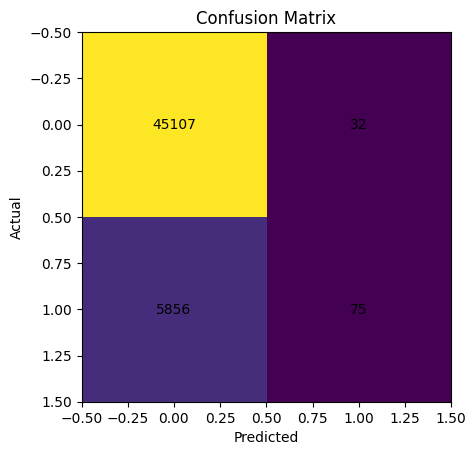

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for (i, j), val in np.ndenumerate(cm):
    plt.text(j, i, int(val), ha='center', va='center')

plt.show()

In [ ]:
# Get feature names after encoding
ohe = model.named_steps["preprocessor"].named_transformers_["cat"]
encoded_features = ohe.get_feature_names_out(cat_cols)

all_features = list(encoded_features) + num_cols

importances = model.named_steps["classifier"].feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(15)

,Feature,Importance
22,Age,0.125605
28,InterestRate,0.122618
23,Income,0.114470
24,LoanAmount,0.102772
26,MonthsEmployed,0.096946
25,CreditScore,0.086799
30,DTIRatio,0.078415
29,LoanTerm,0.036288
27,NumCreditLines,0.029480
10,MaritalStatus_Single,0.010765
